# Introduction

This notebook is intended for a closer look at the mechanisms of "monoGRU" architectures.

We show that these fit subject's data with minimal variability in internal mechanisms.
This let's us reduce the model to a 'cannonical form', with a common computation which we study here.

In [5]:
## setup ##
import os
os.chdir('/ceph/behrens/wsilver/reversal/code/')

from NM_TinyRNN.code.measures import analysis
from NM_TinyRNN.code.measures import mechanistic_variability as mech_var
from NM_TinyRNN.code.measures import plotting_stats
from NM_TinyRNN.code.measures import performance as perf
from NM_TinyRNN.code.measures import reversal_metrics as rev

from NM_TinyRNN.code.models import submit_jobs # this is the code used to train models!

import numpy as np
import pandas as pd
import torch #for testing a few things
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from importlib import reload

CODE_DIR = Path('.') ## OBS THIS MAY NEED TO BE ADJUSTED!
SAVE_PATH = CODE_DIR/'NM_TinyRNN/data/rnns'
DATA_PATH = Path('./NM_TinyRNN/data/AB_behaviour/')

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
#construct analysis_df and have a look at a subset of data!
info_df = submit_jobs.get_DA_info_df() #code used to submit jobs
all_models_df = analysis.get_analysis_df(info_df, mode='all') #code to aggregate all paths and some data
performance_df = perf.get_performance_df(all_models_df) #code to recompute evaluations and aggregate
best_model_df = perf.select_best_outer(performance_df) #
subject_level_df = perf.compute_outer_mean(best_model_df)

print("Available model types (model_type2):")
print(all_models_df.model_type2.unique())

print("\nAvailable columns:")
print([col for col in all_models_df.columns if 'CE' in col or 'type' in col])


Loaded analysis paths from cache: NM_TinyRNN/data/analysis/analysis_df_final.htsv
Loaded performance dataframe from cache: NM_TinyRNN/data/analysis/performance_df_final.htsv
Available model types (model_type2):
['GRU+BC' 'GRU+BC-DB' 'GRU' 'monoGRU+BC' 'monoGRU+BC-DB']

Available columns:
['model_type', 'model_type2']


## Examples from subjects

Let's have a look at the hidden states across all subjects. The should carry an overall motif which we will investigate at the level of network parameters.


<Axes: xlabel='logit_past', ylabel='logit_change'>

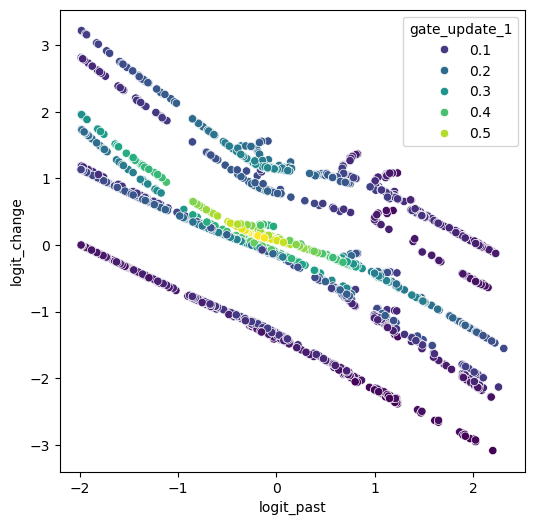

In [59]:
# single subject example
subject_id="WS05"
model_id = "2_unit_monoGRU_relu_unipolar_forced"
outer_loop_n = 10
select_df = best_model_df.query(f"subject_id=='{subject_id}' and model_id=='{model_id}' and outer_loop_n=={outer_loop_n}")

fig, ax = plt.subplots(1,1,figsize=(6,6))
trials_data = analysis.load_data(select_df.trials_data_path.iloc[0])
model = analysis.load_data(select_df.model_pickle_path.iloc[0])
sns.scatterplot(trials_data, x= 'logit_past',y='logit_change', hue='gate_update_1',palette='viridis')

<Axes: xlabel='reversal_trial_index', ylabel='choice'>

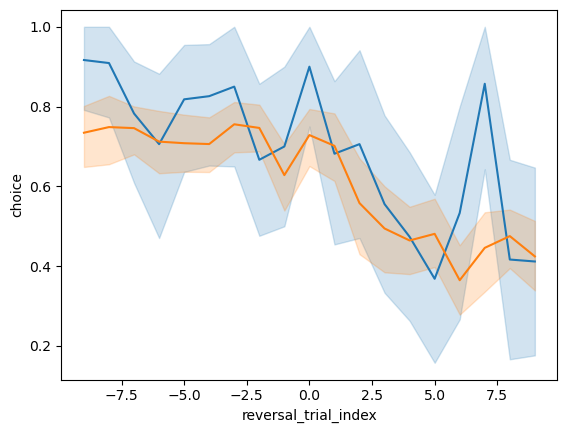

In [60]:
# we want to plot behaviour around reversals
reload(rev)
test = rev.add_reversal_columns(trials_data)
test['prob_A'] = test.groupby('session_folder_name', sort=False)['prob_A'].shift(1)
test['prob_B'] = test.groupby('session_folder_name', sort=False)['prob_B'].shift(1)
test = test.query('forced_choice == 0')
fig, ax = plt.subplots()
sns.lineplot(test.query('reversal_type=="RL" and reversal_trial_index>-10 and reversal_trial_index<10'),
             x='reversal_trial_index',
             y='choice',
             ax=ax)
sns.lineplot(test.query('reversal_type=="RL" and reversal_trial_index>-10 and reversal_trial_index<10'),
             x='reversal_trial_index',
             y='prob_B',
             ax=ax)


[Text(0.5, 0, 'Trial relative to reversal'),
 Text(0, 0.5, 'P(choose best initial arm)')]

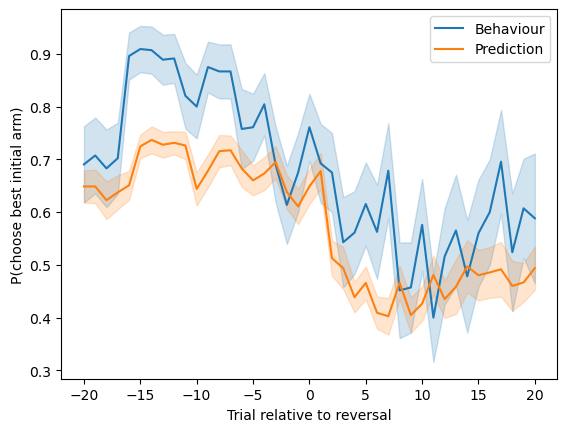

In [61]:
reload(rev)

reversal_data = rev.collapse_reversal_data(trials_data)
reversal_data = reversal_data.query('forced_choice == 0')
fig, ax = plt.subplots()
sns.lineplot(reversal_data, x='reversal_trial_index', y='choice_initial', errorbar='se', ax=ax, label='Behaviour')
sns.lineplot(reversal_data, x='reversal_trial_index', y='prob_initial', errorbar='se', ax=ax, label='Prediction')
ax.set(xlabel='Trial relative to reversal', ylabel='P(choose best initial arm)')


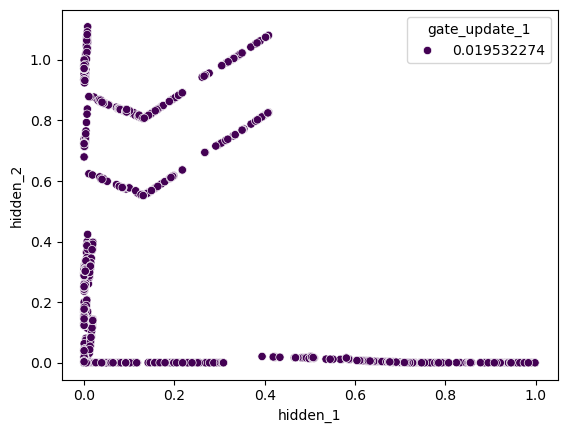

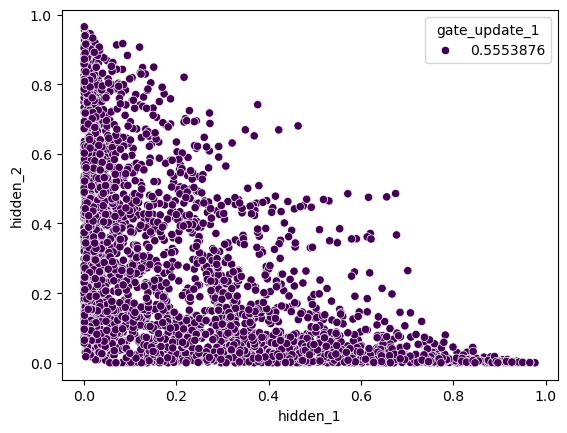

In [62]:
# we want to run the model through twice
reload(rev)
(z_low, z_high) = trials_data.gate_update_1.quantile([0.01,0.99]).values
trials_data_files = []
for z in [z_low, z_high]:
    z_tensor = torch.tensor(z,dtype =torch.float32).unsqueeze(0).unsqueeze(0)
    fixed_gates = {'z_t':z_tensor}
    trials_data_new = rev._run_model_on_trials_data(model,trials_data, fixed_gates = fixed_gates)
    trials_data_files.append(trials_data_new)
    sns.scatterplot(x=trials_data_new['hidden_1'], y=trials_data_new['hidden_2'], 
                hue=trials_data_new['gate_update_1'], palette='viridis')
    plt.show()



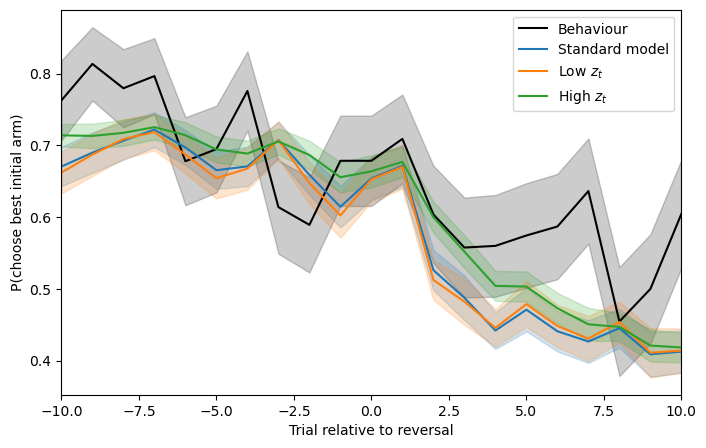

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))
reload(rev)

reversal_data = rev.collapse_reversal_data(trials_data)
reversal_data = reversal_data.query('-10 <= reversal_trial_index <= 10')

sns.lineplot(reversal_data,
             x='reversal_trial_index',
             y='choice_initial',
             errorbar='se', ax=ax, color='black',
             label='Behaviour')
sns.lineplot(reversal_data,
             x='reversal_trial_index',
             y='prob_initial',
             errorbar='se', ax=ax, color='tab:blue',
             label='Standard model')

prediction_labels = ['Low $z_t$', 'High $z_t$']
prediction_colors = ['tab:orange', 'tab:green']
for df, label, color in zip(trials_data_files, prediction_labels, prediction_colors):
    reversal_df = rev.collapse_reversal_data(df)
    reversal_df = reversal_df.query('-10 <= reversal_trial_index <= 10')
    sns.lineplot(reversal_df,
                 x='reversal_trial_index',
                 y='prob_initial',
                 errorbar='se', ax=ax, color=color,
                 label=label)

ax.set(xlabel='Trial relative to reversal',
       ylabel='P(choose best initial arm)',
       xlim=(-10, 10))
ax.legend()


In [64]:
# Run held-out reversal analysis across all subjects for one model_id
reload(rev)

analysis_model_id = model_id
selected_models = best_model_df.query(
    'model_id == @analysis_model_id'
).reset_index(drop=True)

all_reversal_data = []

for _, model_row in selected_models.iterrows():
    subject_trials = analysis.load_data(model_row.trials_data_path)
    subject_model = analysis.load_data(model_row.model_pickle_path)
    z_low, z_high = subject_trials.gate_update_1.quantile([0.01, 0.99]).values
    subject_trials = subject_trials.query('split=="eval"')
    model_trials = {
        'Standard model': subject_trials,
    }
    for z, label in [(z_low, 'Low $z_t$'), (z_high, 'High $z_t$')]:
        z_tensor = torch.tensor(
            z, dtype=torch.float32
        ).unsqueeze(0).unsqueeze(0)
        fixed_gates = {'z_t': z_tensor}
        model_trials[label] = rev._run_model_on_trials_data(
            subject_model,
            subject_trials,
            fixed_gates=fixed_gates,
        )

    for condition, condition_trials in model_trials.items():
        condition_data = rev.collapse_reversal_data(condition_trials)
        condition_data = condition_data.query(
            'split == "eval" and -20 <= reversal_trial_index <= 20'
        ).copy()
        condition_data['subject_id'] = model_row.subject_id
        condition_data['model_id'] = model_row.model_id
        condition_data['outer_loop_n'] = model_row.outer_loop_n
        condition_data['condition'] = condition
        all_reversal_data.append(condition_data)

all_reversal_data = pd.concat(all_reversal_data, ignore_index=True)
print(
    f'Analysed {len(selected_models)} held-out outer-fold models and '
    f'{len(all_reversal_data)} aligned rows.'
)


Analysed 110 held-out outer-fold models and 112722 aligned rows.


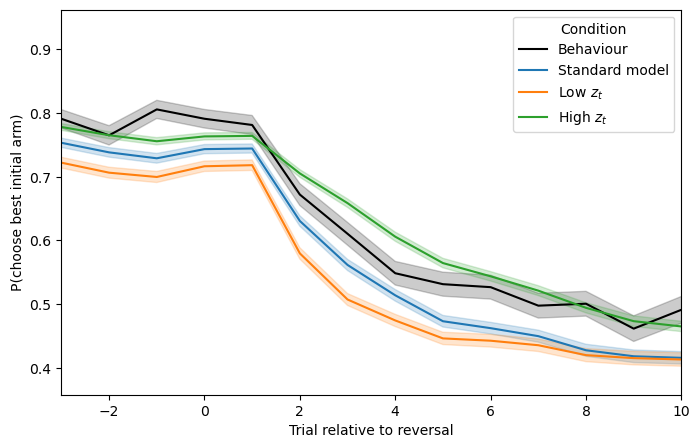

In [48]:

fig, ax = plt.subplots(figsize=(8, 5))
behaviour_data = all_reversal_data.query(
    'condition == "Standard model" and forced_choice == 0'
)
sns.lineplot(
    behaviour_data,
    x='reversal_trial_index',
    y='choice_initial',
    errorbar='se',
    ax=ax,
    color='black',
    label='Behaviour',
)

prediction_colors = {
    'Standard model': 'tab:blue',
    'Low $z_t$': 'tab:orange',
    'High $z_t$': 'tab:green',
}
for condition, color in prediction_colors.items():
    prediction_data = all_reversal_data.query(
        'condition == @condition and forced_choice == 0'
    )
    sns.lineplot(
        prediction_data,
        x='reversal_trial_index',
        y='prob_initial',
        errorbar='se',
        ax=ax,
        color=color,
        label=condition,
    )

ax.set(
    xlabel='Trial relative to reversal',
    ylabel='P(choose best initial arm)',
    xlim=(-3, 10),
)
ax.legend(title='Condition')


<Axes: xlabel='reversal_trial_index', ylabel='choice_initial'>

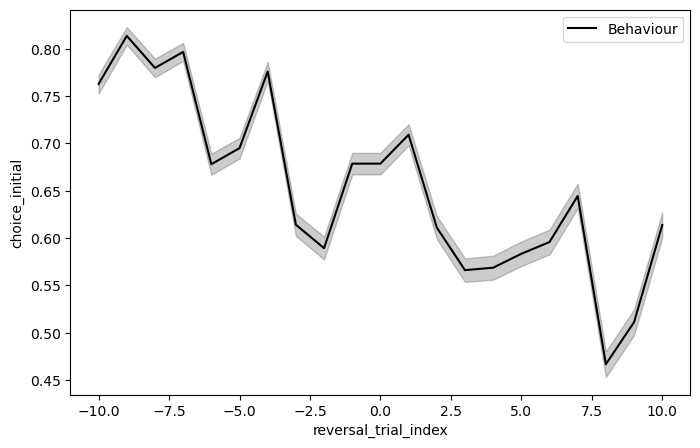

In [154]:
subject_data = all_reversal_data.query('subject_id== "WS05"')
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(subject_data, x='reversal_trial_index', y='choice_initial', 
             errorbar='se', ax=ax, color='black', label='Behaviour')


In [31]:
behaviour_data.groupby('subject_id').count()

,hidden_1,hidden_2,gate_update_1,forced_choice,choice,outcome,good_poke,session_folder_name,session_trial_idx,sequence_block_idx,...,prob_A,prob_B,split,is_reversal,reversal_trial_index,reversal_type,choice_initial,prob_initial,model_id,condition
subject_id,,,,,,,,,,,,,,,,,,,,,
WS01,18230,18230,18230,18230,18230,18230,18230,18230,18230,17600,...,18220,18220,18230,18230,18230,18230,18230,18220,18230,18230
WS02,21080,21080,21080,21080,21080,21080,21080,21080,21080,20470,...,21070,21070,21080,21080,21080,21080,21080,21070,21080,21080
WS05,15200,15200,15200,15200,15200,15200,15200,15200,15200,14220,...,15180,15180,15200,15200,15200,15200,15200,15180,15200,15200
WS08,27310,27310,27310,27310,27310,27310,27310,27310,27310,26410,...,27290,27290,27310,27310,27310,27310,27310,27290,27310,27310
WS09,19500,19500,19500,19500,19500,19500,19500,19500,19500,18730,...,19490,19490,19500,19500,19500,19500,19500,19490,19500,19500
WS10,29590,29590,29590,29590,29590,29590,29590,29590,29590,28950,...,29540,29540,29590,29590,29590,29590,29590,29540,29590,29590
WS13,35760,35760,35760,35760,35760,35760,35760,35760,35760,35320,...,35760,35760,35760,35760,35760,35760,35760,35760,35760,35760
WS14,34610,34610,34610,34610,34610,34610,34610,34610,34610,33570,...,34610,34610,34610,34610,34610,34610,34610,34610,34610,34610
WS16,27890,27890,27890,27890,27890,27890,27890,27890,27890,27290,...,27870,27870,27890,27890,27890,27890,27890,27870,27890,27890


Behaviour at reversal (reversal_trial_index == 0):
 mean_across_subjects
             0.428539

Mean behaviour over the plotted window:
0.516770740282645


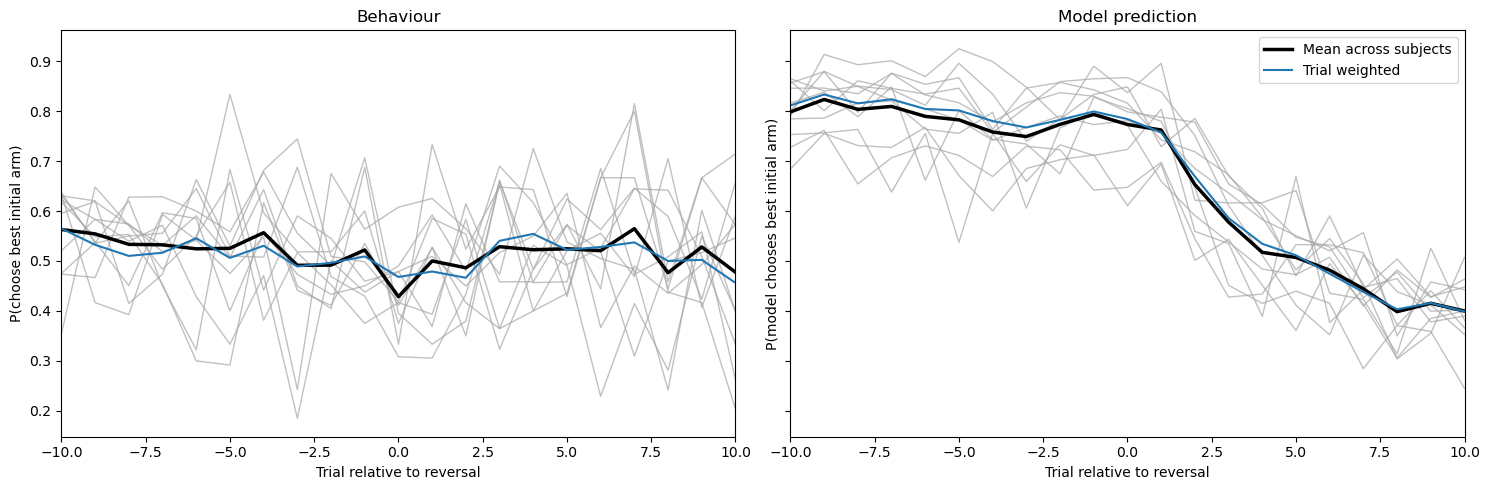

In [38]:
# Compare weighting schemes for behaviour and model predictions
behaviour_data = all_reversal_data.query(
    'condition == "Standard model" and forced_choice == 1'
).copy()

# Outer-fold rows duplicate the same subject behaviour. Collapse those rows,
# then average sessions equally within each subject.
session_level = (
    behaviour_data
    .groupby(
        ['subject_id', 'session_folder_name', 'reversal_trial_index'],
        as_index=False,
    )[['choice_initial', 'prob_initial']]
    .mean()
)
subject_level = (
    session_level
    .groupby(['subject_id', 'reversal_trial_index'], as_index=False)
    .mean(numeric_only=True)
)

trial_weighted = (
    behaviour_data
    .groupby('reversal_trial_index', as_index=False)[
        ['choice_initial', 'prob_initial']
    ]
    .mean()
)
subject_weighted = (
    subject_level
    .groupby('reversal_trial_index', as_index=False)[
        ['choice_initial', 'prob_initial']
    ]
    .mean()
)

print('Behaviour at reversal (reversal_trial_index == 0):')
print(
    subject_weighted.query('reversal_trial_index == 0')
    [['choice_initial']]
    .rename(columns={'choice_initial': 'mean_across_subjects'})
    .to_string(index=False)
)
print('\nMean behaviour over the plotted window:')
print(
    subject_weighted
    .query('-10 <= reversal_trial_index <= 10')['choice_initial']
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
plot_window = '-10 <= reversal_trial_index <= 10'

for subject_id, subject_data in subject_level.groupby('subject_id'):
    subject_data = subject_data.query(plot_window)
    axes[0].plot(
        subject_data['reversal_trial_index'],
        subject_data['choice_initial'],
        color='0.65',
        linewidth=1,
        alpha=0.7,
    )
    axes[1].plot(
        subject_data['reversal_trial_index'],
        subject_data['prob_initial'],
        color='0.65',
        linewidth=1,
        alpha=0.7,
    )

subject_plot = subject_weighted.query(plot_window)
trial_plot = trial_weighted.query(plot_window)
for axis, value_column, ylabel in [
    (axes[0], 'choice_initial', 'P(choose best initial arm)'),
    (axes[1], 'prob_initial', 'P(model chooses best initial arm)'),
]:
    axis.plot(
        subject_plot['reversal_trial_index'],
        subject_plot[value_column],
        color='black',
        linewidth=2.5,
        label='Mean across subjects',
    )
    axis.plot(
        trial_plot['reversal_trial_index'],
        trial_plot[value_column],
        color='tab:blue',
        linewidth=1.5,
        label='Trial weighted',
    )
    axis.set(
        xlabel='Trial relative to reversal',
        ylabel=ylabel,
        xlim=(-10, 10),
    )

axes[0].set_title('Behaviour')
axes[1].set_title('Model prediction')
axes[1].legend()
fig.tight_layout()


In [44]:
# Check held-out filtering and reversal recoding
heldout_reversal_data = []
for _, model_row in selected_models.iterrows():
    subject_trials = analysis.load_data(model_row.trials_data_path)
    condition_data = rev.collapse_reversal_data(subject_trials)
    condition_data = condition_data.query(
        'split == "eval" and -10 <= reversal_trial_index <= 10'
    ).copy()
    condition_data['subject_id'] = model_row.subject_id
    condition_data['model_id'] = model_row.model_id
    condition_data['outer_loop_n'] = model_row.outer_loop_n
    heldout_reversal_data.append(condition_data)

prediction_check = pd.concat(heldout_reversal_data, ignore_index=True)
print(
    f'Held-out rows: {len(prediction_check)}; '
    f'subjects: {prediction_check.subject_id.nunique()}; '
    f'model folds: {prediction_check[["subject_id", "outer_loop_n"]].drop_duplicates().shape[0]}'
)

forced_summary = (
    prediction_check
    .groupby('forced_choice')[['choice_initial', 'prob_initial']]
    .agg(['mean', 'count'])
)
print('Choice and prediction by target forced-choice status:')
print(forced_summary)

print('\nAt reversal (reversal_trial_index == 0):')
print(
    prediction_check
    .query('reversal_trial_index == 0')
    .groupby('forced_choice')[['choice_initial', 'prob_initial']]
    .mean()
)

# Verify that the collapsed recoding is equivalent to selecting the arm that
# was good before the reversal, for both choices and shifted predictions.
for reversal_type, expected_initial_best in [('LR', 0), ('RL', 1)]:
    subset = prediction_check.query('reversal_type == @reversal_type')
    choice_expected = (
        subset['choice'] == expected_initial_best
    ).astype(float)
    probability_column = 'prob_A' if expected_initial_best == 0 else 'prob_B'
    probability_expected = subset[probability_column]
    print(
        f'{reversal_type}: choice recoding matches = '
        f'{np.array_equal(subset.choice_initial.to_numpy(), choice_expected.to_numpy())}; '
        f'prediction recoding matches = '
        f'{np.allclose(subset.prob_initial, probability_expected, equal_nan=True)}'
    )


Held-out rows: 20919; subjects: 11; model folds: 110
Choice and prediction by target forced-choice status:
              choice_initial        prob_initial       
                        mean  count         mean  count
forced_choice                                          
0                   0.719286  15685     0.658713  15685
1                   0.514329   5234     0.681576   5234

At reversal (reversal_trial_index == 0):
               choice_initial  prob_initial
forced_choice                              
0                    0.792041      0.743564
1                    0.474308      0.783323
LR: choice recoding matches = True; prediction recoding matches = True
RL: choice recoding matches = True; prediction recoding matches = True


# Computational motif in weights

In [177]:
# Average parameters across all outer-loop models for one subject and model_id
import copy


def average_subject_model_parameters(best_model_df, subject_id, model_id):
    if subject_id == "all":
        selected_models = best_model_df.query(
            'model_id == @model_id'
        ).reset_index(drop=True)
    else:
        selected_models = best_model_df.query(
            'subject_id==@subject_id and model_id == @model_id'
    ).reset_index(drop=True)
    if selected_models.empty:
        raise ValueError(
            f'No models found for subject_id={subject_id!r}, '
            f'model_id={model_id!r}'
        )

    models = [
        analysis.load_data(path)
        for path in selected_models.model_pickle_path
    ]
    reference_state = models[0].state_dict()

    for current_model in models[1:]:
        current_state = current_model.state_dict()
        if set(current_state) != set(reference_state):
            raise ValueError('Models do not have matching state_dict keys.')
        for parameter_name in reference_state:
            if current_state[parameter_name].shape != reference_state[parameter_name].shape:
                raise ValueError(
                    f'Mismatched shape for {parameter_name!r}.'
                )

    averaged_state = {}
    for parameter_name, reference_value in reference_state.items():
        values = [
            current_model.state_dict()[parameter_name]
            for current_model in models
        ]
        if reference_value.is_floating_point() or reference_value.is_complex():
            averaged_state[parameter_name] = torch.stack(values).mean(dim=0)
        else:
            if not all(torch.equal(value, values[0]) for value in values[1:]):
                raise ValueError(
                    f'Non-floating state {parameter_name!r} differs across models.'
                )
            averaged_state[parameter_name] = values[0].clone()

    averaged_model = copy.deepcopy(models[0])
    averaged_model.load_state_dict(averaged_state)
    return averaged_model, selected_models


averaged_model, averaged_model_rows = average_subject_model_parameters(
    best_model_df,
    subject_id='all',
    model_id=model_id,
)
print(
    f'Averaged {len(averaged_model_rows)} models across all models'
)


Averaged 110 models across all models


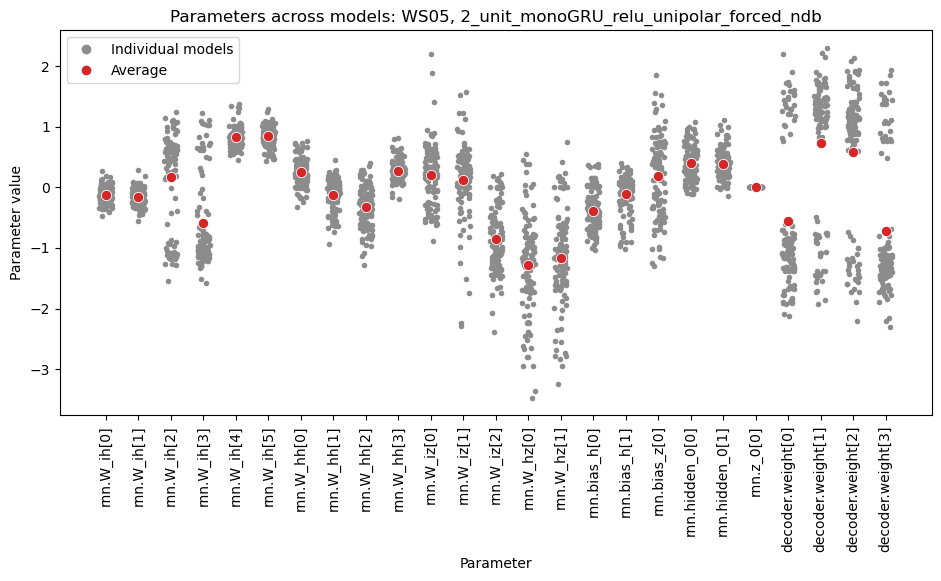

In [182]:
# Visualise individual parameters and their across-model averages
from matplotlib.lines import Line2D

parameter_records = []

for model_number, model_path in enumerate(averaged_model_rows.model_pickle_path):
    current_model = analysis.load_data(model_path)
    for parameter_name, parameter in current_model.named_parameters():
        for parameter_index, value in enumerate(parameter.detach().cpu().reshape(-1).numpy()):
            parameter_records.append({
                'parameter': f'{parameter_name}[{parameter_index}]',
                'model_number': model_number,
                'value': value,
            })

parameter_data = pd.DataFrame(parameter_records)
parameter_means = (
    parameter_data
    .groupby('parameter', as_index=False)['value']
    .mean()
    .rename(columns={'value': 'average_value'})
)

fig, ax = plt.subplots(
    figsize=(max(10, 0.45 * parameter_data['parameter'].nunique()), 5)
)
sns.stripplot(
    parameter_data,
    x='parameter',
    y='value',
    color='0.55',
    size=4,
    jitter=0.2,
    ax=ax,
)
sns.scatterplot(
    parameter_means,
    x='parameter',
    y='average_value',
    color='tab:red',
    s=55,
    zorder=3,
    ax=ax,
)
ax.set(
    xlabel='Parameter',
    ylabel='Parameter value',
    title=f'Parameters across models: {subject_id}, {model_id}',
)
ax.tick_params(axis='x', rotation=90)
ax.legend(
    handles=[
        Line2D([], [], marker='o', linestyle='', color='0.55', label='Individual models'),
        Line2D([], [], marker='o', linestyle='', color='tab:red', label='Average'),
    ]
)


Text(0.5, 1.02, 'Averaged network parameters: WS05, 2_unit_monoGRU_relu_unipolar_forced_ndb')

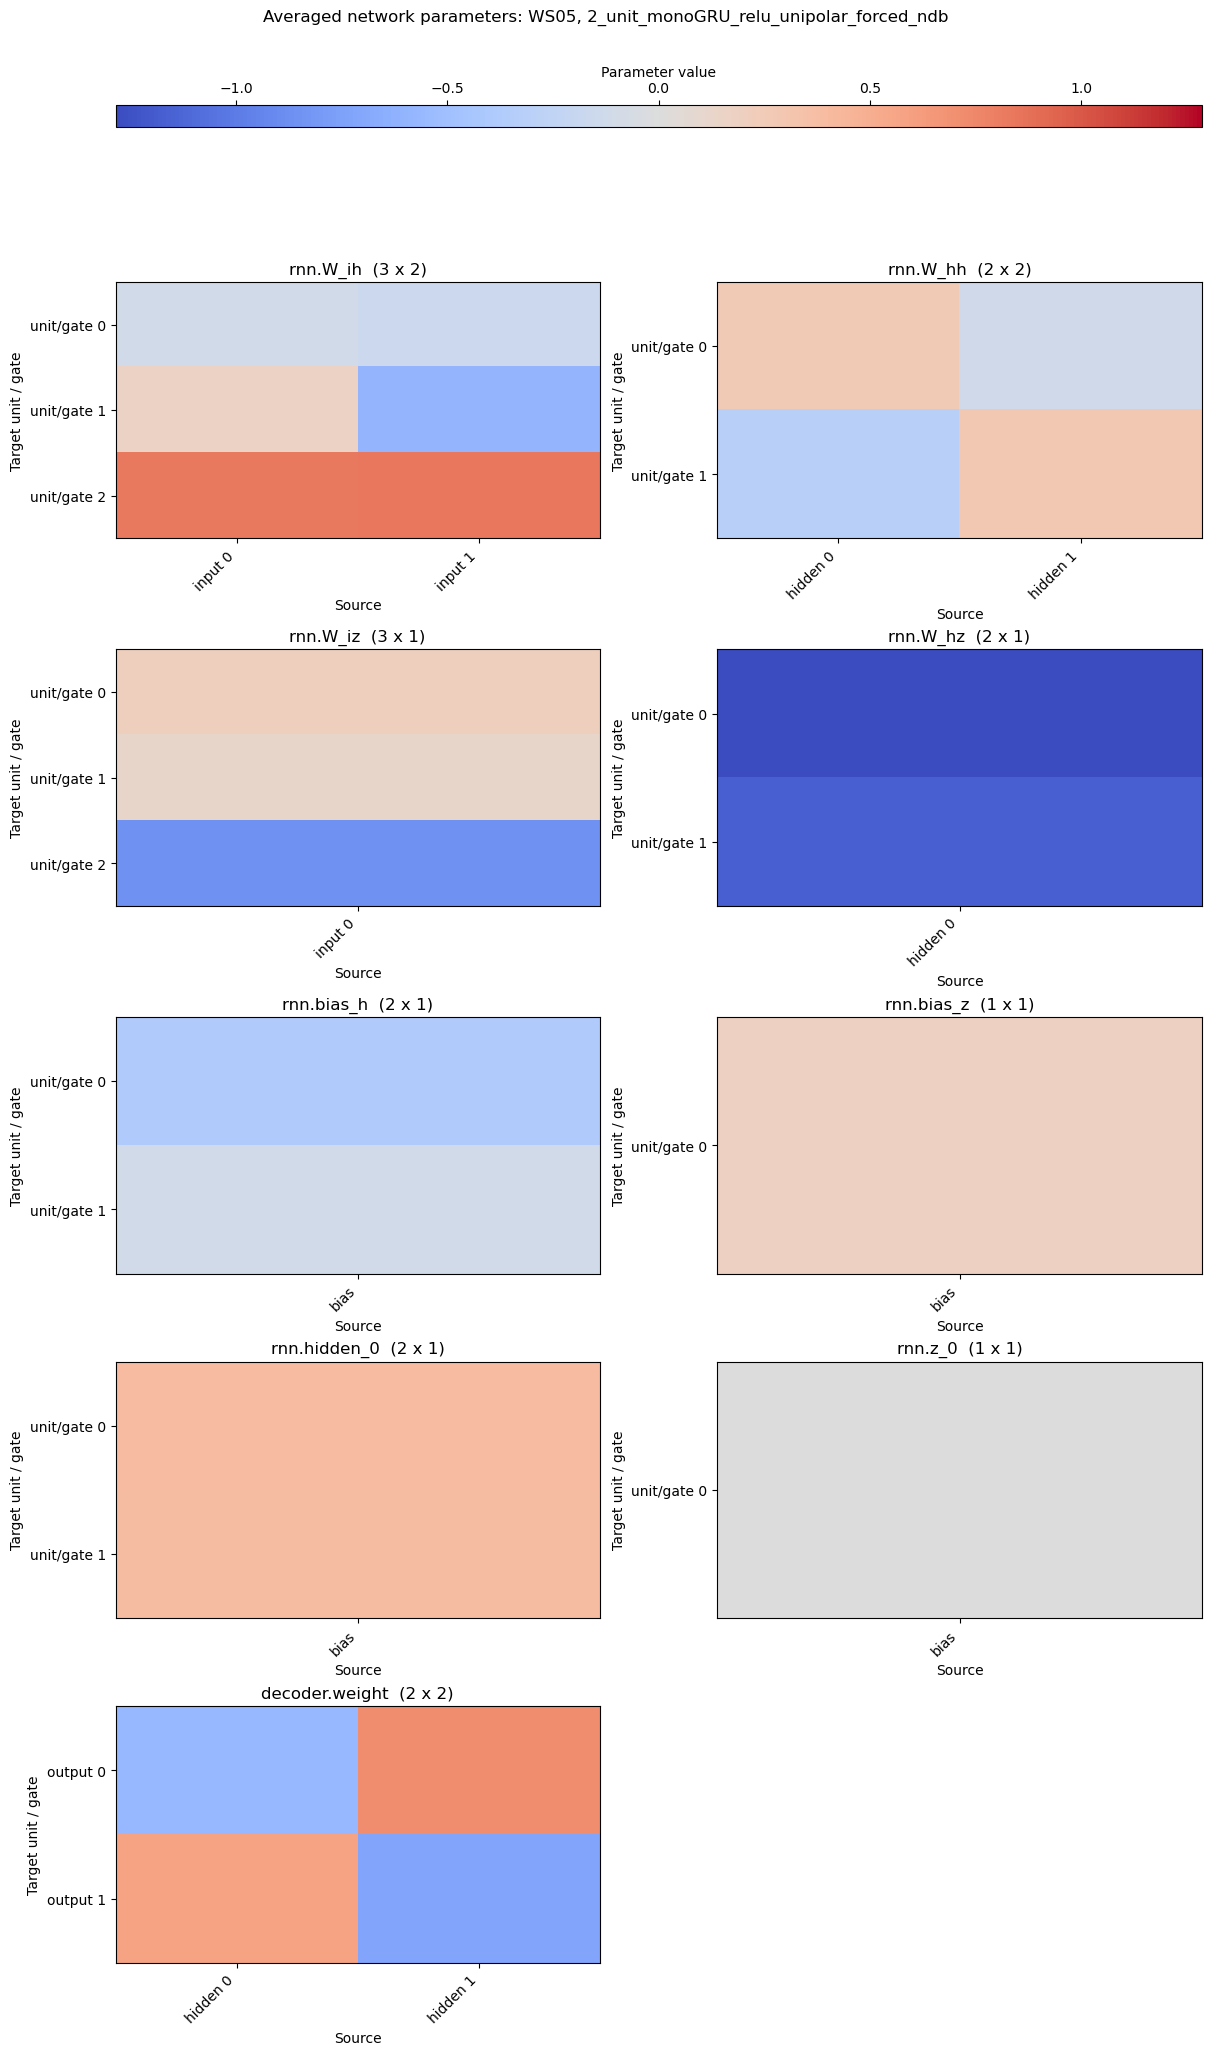

In [173]:
# Plot averaged parameters with a shared zero-centred colour scale
from matplotlib.colors import TwoSlopeNorm

plot_parameters = []
for name, parameter in averaged_model.named_parameters():
    parameter = parameter.detach().cpu()
    is_bias = parameter.ndim < 2
    parameter_matrix = parameter.reshape(-1, 1) if is_bias else parameter
    plot_parameters.append((name, parameter_matrix, is_bias))

max_abs_value = max(
    float(parameter.abs().max())
    for _, parameter, _ in plot_parameters
)
colour_norm = TwoSlopeNorm(
    vmin=-max_abs_value,
    vcenter=0,
    vmax=max_abs_value,
)

n_columns = 2
n_rows = int(np.ceil(len(plot_parameters) / n_columns))
fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(12, 4 * n_rows),
    squeeze=False,
    constrained_layout=True,
)
axes = axes.ravel()

for axis, (name, parameter, is_bias) in zip(axes, plot_parameters):
    image = axis.imshow(
        parameter.numpy(),
        cmap='coolwarm',
        norm=colour_norm,
        aspect='auto',
        interpolation='nearest',
    )
    axis.set_title(f'{name}  ({parameter.shape[0]} x {parameter.shape[1]})')

    if is_bias:
        source_labels = ['bias']
        target_labels = [f'unit/gate {index}' for index in range(parameter.shape[0])]
    else:
        source_labels = [
            f'input {index}' if '.W_i' in name else f'hidden {index}'
            for index in range(parameter.shape[1])
        ]
        target_labels = [
            f'output {index}' if 'decoder' in name else f'unit/gate {index}'
            for index in range(parameter.shape[0])
        ]

    axis.set_xlabel('Source')
    axis.set_ylabel('Target unit / gate')
    axis.set_xticks(range(parameter.shape[1]))
    axis.set_yticks(range(parameter.shape[0]))
    axis.set_xticklabels(source_labels, rotation=45, ha='right')
    axis.set_yticklabels(target_labels)

for axis in axes[len(plot_parameters):]:
    axis.remove()

fig.colorbar(
    image,
    ax=axes[:len(plot_parameters)].tolist(),
    orientation='horizontal',
    location='top',
    fraction=0.03,
    pad=0.08,
    aspect=50,
    label='Parameter value',
)
fig.suptitle(
    f'Averaged network parameters: {subject_id}, {model_id}',
    y=1.02,
)


In [185]:
torch.tensor([1,0],dtype=torch.float32)@averaged_model.rnn.W_hh

tensor([ 0.2511, -0.1214], grad_fn=<SqueezeBackward4>)

In [215]:
# Compare the raw RL diagnostic with the collapsed RL data row by row
indexed_trials = trials_data.copy()
indexed_trials['trial_row'] = np.arange(len(indexed_trials))

raw_reversal = rev.add_reversal_columns(indexed_trials).copy()
raw_reversal['prob_B_aligned'] = (
    raw_reversal
    .groupby('session_folder_name', sort=False)['prob_B']
    .shift(1)
)

collapsed_reversal = rev.collapse_reversal_data(indexed_trials).copy()

raw_rl = raw_reversal.query(
    'reversal_type == "RL" and forced_choice == 0 '
    'and -10 <= reversal_trial_index <= 10'
)[['trial_row', 'choice', 'prob_B_aligned']]
collapsed_rl = collapsed_reversal.query(
    'reversal_type == "RL" and forced_choice == 0 '
    'and -10 <= reversal_trial_index <= 10'
)[['trial_row', 'choice_initial', 'prob_initial']]

comparison = raw_rl.merge(collapsed_rl, on='trial_row', how='outer')
comparison['choice_difference'] = (
    comparison['choice'] - comparison['choice_initial']
).abs()
comparison['prediction_difference'] = (
    comparison['prob_B_aligned'] - comparison['prob_initial']
).abs()
print(comparison[['choice_difference', 'prediction_difference']].max())
print(f'RL raw rows: {len(raw_rl)}, collapsed rows: {len(collapsed_rl)}')


choice_difference        0.0
prediction_difference    0.0
dtype: float64
RL raw rows: 401, collapsed rows: 401
